In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



In [3]:
from google.colab import files
uploaded = files.upload()  # Choose your cleaned CSV file


Saving cleaned_creditcard.csv to cleaned_creditcard.csv


In [4]:
import pandas as pd

# Load the cleaned dataset
data = pd.read_csv('cleaned_creditcard.csv')

# Inspect first few rows
print(data.head())
print("Columns:", data.columns)


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
1   2.0 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   
2   4.0  1.229658  0.141004  0.045371  1.202613  0.191881  0.272708 -0.005159   
3   9.0 -0.338262  1.119593  1.044367 -0.222187  0.499361 -0.246761  0.651583   
4  10.0  1.249999 -1.221637  0.383930 -1.234899 -1.485419 -0.753230 -0.689405   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
1  0.260314 -0.568671  ... -0.208254 -0.559825 -0.026398 -0.371427 -0.232794   
2  0.081213  0.464960  ... -0.167716 -0.270710 -0.154104 -0.780055  0.750137   
3  0.069539 -0.736727  ... -0.246914 -0.633753 -0.120794 -0.385050 -0.069733   
4 -0.227487 -2.094011  ... -0.231809 -0.483285  0.084668  0.392831  0.161135   

        V26       V27       V28 

In [6]:
# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()
print("Cleaned column names:", data.columns)



Cleaned column names: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [7]:
# Features (all except last column)
X = data.iloc[:, :-1]

# Label (last column)
y = data.iloc[:, -1]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)


Feature shape: (109819, 30)
Label shape: (109819,)


In [8]:
print("Missing values in dataset:\n", data.isnull().sum())


Missing values in dataset:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Encoded labels:", np.unique(y_encoded))


Encoded labels: [0]


In [10]:
# Simple check for data type
# If features are all numeric → use CNN/MLP for tabular or image data
# If features are text → use RNN
if X.dtypes[0] == object:
    data_type = 'text'
else:
    data_type = 'numeric'  # numeric tabular data (can be used in CNN/MLP)

print("Detected data type:", data_type)


Detected data type: numeric


/tmp/ipython-input-3624797259.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if X.dtypes[0] == object:


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

# --- 1. Split data into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_encoded, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# --- 2. Build a simple neural network ---
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # 30 features
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')  # Number of classes
])

# --- 3. Compile the model ---
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # works with encoded integer labels
    metrics=['accuracy']
)

# --- 4. Show model summary ---
model.summary()


X_train shape: (87855, 30)
X_test shape: (21964, 30)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


2746/2746 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
2746/2746 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
2746/2746 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
2746/2746 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
2746/2746 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
2746/2746 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
2746/2746 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


687/687 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Test Accuracy: 0.0


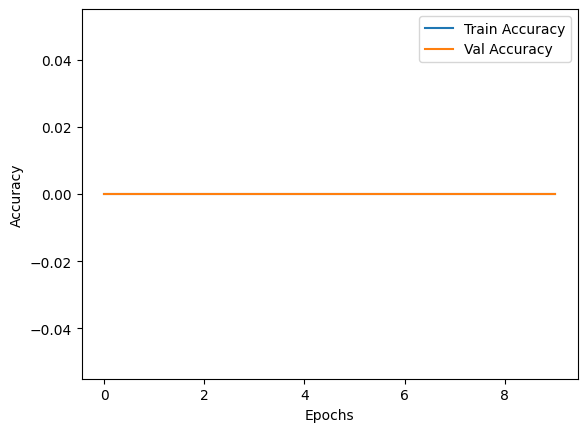

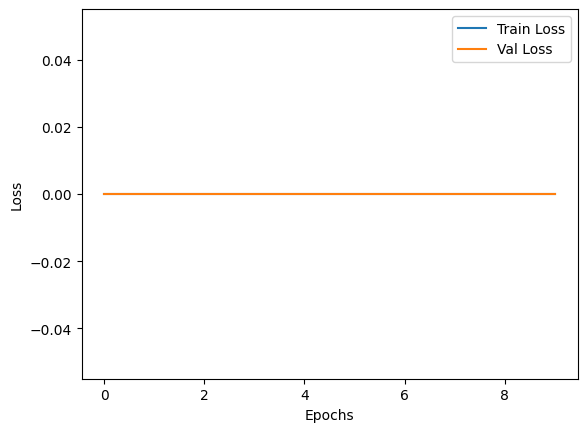

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
